#Makine Öğrenmesi

📘 Makine Öğrenmesi Dokümantasyonu

Steam Dataset 2025 – Fiyatlandırma & Pazar Dinamikleri Analitiği

Bu doküman, proje kapsamında geliştirilecek üç farklı makine öğrenmesi modelinin amaçlarını, kullanılacak veri yapısını, gereken kolonları, dönüşüm adımlarını ve modelleme sürecini tanımlar.

-------------------------------------------------------
📌 Genel Feature Engineering Planı
1. Tarih kolonu dönüşümü

2. Kategorik kolonlar → One-hot encoding

genre_name

detailed_genre_group

gameplay_type

cpu/gpu brand kolonları

categories_all → multi-label explode → one-hot

3. Boolean kolonlar → int
df[col] = df[col].astype(int)

4. Eksik değer doldurma

Numeric → median

Categorical → mode (most frequent)

5. Normalizasyon / Standartlaştırma (opsiyonel)

StandartScaler (linear modeller için)

-------------------------------------------------------
📦 Sonuç: Hangi Kolonları Tutuyoruz?

Aşağıdaki kolon seti üç modeli de kapsar ve gereksiz hiçbir şey içermez:

[
 'release_date', 'release_year',
 'type', 'is_free', 'is_indie', 'is_mature_content',
 'genre_name', 'detailed_genre_group', 'categories_all',
 'gameplay_type', 'has_singleplayer', 'has_multiplayer',
 'system_req_level', 'ram_min_gb', 'ram_rec_gb',
 'cpu_brand_min', 'cpu_brand_rec',
 'gpu_brand_min', 'gpu_brand_rec',
 'supports_windows', 'supports_mac', 'supports_linux',
 'total_platform_count',
 'mat_initial_price_usd', 'mat_final_price_usd',
 'estimated_sales', 'estimated_revenue_usd'
]

🔥 Not – Leakage Uyarısı

Aşağıdaki kolonlar “çıktı sonrası sinyaller” olduğu için
mutlaka modele dahil edilmemelidir:

metacritic_score

recommendations_total

popularity_tier

Bunlar satıştan sonra oluşan verilerdir → geleceğe dönük tahminde yanlış sonuç verir.

Dönüşümler

→ Aynı fiyat modeliyle aynıdır:

One-hot encoding

Boolean → 0/1

Numeric scaling

Eksik değer doldurma

Modelleme Yaklaşımı

Random Forest Regressor

XGBoost / LightGBM

Gradient Boosting Regressor

Poisson Regression (count data için alternatif)

Çıktı

“Bu oyunun tahmini satış adedi X.”

“Bu oyunun potansiyel geliri Y$.”

Feature importance → satış üzerinde etkili faktörler

In [ ]:
from google.cloud import bigquery
from google.colab import auth
import pandas as pd

# 1. Kimlik Doğrulama
auth.authenticate_user()

# 2. Proje Ayarları (Burayı kendi ID'n ile değiştirmeyi unutma)
project_id = 'workintech-bootcamp-atakan-can'
dataset_id = 'Team6_Steam'

In [ ]:
table_name = 'lkapplications'

# BigQuery İstemcisini Başlat
client = bigquery.Client(project=project_id)

# 3. Tüm Veriyi Çeken Sorgu (LIMIT yok)
query = f"""
    SELECT * FROM `{project_id}.{dataset_id}.{table_name}`
"""

print(f"⏳ '{table_name}' tablosunun tamamı indiriliyor, lütfen bekleyin...")

# 4. Sorguyu Çalıştır ve DataFrame'e Çevir
df_lkapplications = client.query(query).to_dataframe()

# 5. Sonuçları Göster
print(f"✅ İŞLEM TAMAM! Toplam {len(df_lkapplications)} satır veri çekildi.")
print(f"Tablo Boyutu: {df_lkapplications.shape}")

# İlk 5 satırı göster
display(df_lkapplications.info())

⏳ 'lkapplications' tablosunun tamamı indiriliyor, lütfen bekleyin...
✅ İŞLEM TAMAM! Toplam 187483 satır veri çekildi.
Tablo Boyutu: (187483, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187483 entries, 0 to 187482
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   release_date           187483 non-null  dbdate 
 1   appid                  187483 non-null  Int64  
 2   name                   187483 non-null  object 
 3   type                   187483 non-null  object 
 4   is_free                187483 non-null  boolean
 5   required_age           187483 non-null  float64
 6   metacritic_score       5057 non-null    float64
 7   recommendations_total  187483 non-null  float64
 8   mat_supports_windows   187483 non-null  object 
 9   mat_supports_mac       187483 non-null  object 
 10  mat_supports_linux     187483 non-null  object 
 11  release_year           187483 non-null  float64
 1

None

In [ ]:
# 1) Tutmak istediğimiz kolonların listesi
cols_ml = [
    "release_date",

    "type", "is_free", "is_indie", "is_mature_content",
    "genre_name", "detailed_genre_group", "categories_all",
    "gameplay_type", "has_singleplayer", "has_multiplayer",

    "system_req_level", "ram_min_gb", "ram_rec_gb",
    "cpu_brand_min", "cpu_brand_rec",
    "gpu_brand_min", "gpu_brand_rec",

    "supports_windows", "supports_mac", "supports_linux",
    "total_platform_count",

    "mat_initial_price_usd", "mat_final_price_usd",

    "estimated_sales", "estimated_revenue_usd"
]

# 2) Sadece bu kolonları içeren yeni dataframe
df_ml = df_lkapplications[cols_ml]

df_ml.head()


,release_date,type,is_free,is_indie,is_mature_content,genre_name,detailed_genre_group,categories_all,gameplay_type,has_singleplayer,...,gpu_brand_min,gpu_brand_rec,supports_windows,supports_mac,supports_linux,total_platform_count,mat_initial_price_usd,mat_final_price_usd,estimated_sales,estimated_revenue_usd
0,2024-06-10,demo,True,False,False,Unknown,Unclassified,Co-op | Game Demo | Multiplayer | Remote Play ...,Both SP & MP,True,...,unknown,unknown,1,0,0,1,0.0,0.0,0.0,0.0
1,2025-05-28,demo,True,False,False,Unknown,Unclassified,Game Demo | Single-player,Single-player only,True,...,unknown,unknown,1,0,0,1,0.0,0.0,0.0,0.0
2,2024-03-01,music,True,False,False,Free To Play,Free to Play,Unknown,Unknown,False,...,unknown,unknown,1,1,1,3,0.0,0.0,0.0,0.0
3,2025-02-12,demo,True,False,False,Unknown,Unclassified,Game Demo | Single-player,Single-player only,True,...,unknown,unknown,1,0,0,1,0.0,0.0,0.0,0.0
4,2020-10-15,demo,True,True,False,Adventure | Indie | RPG,Indie Action RPG,Game Demo | Single-player | Steam Achievements...,Single-player only,True,...,unknown,unknown,1,1,1,3,0.0,0.0,0.0,0.0


In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187483 entries, 0 to 187482
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   release_date           187483 non-null  dbdate 
 1   type                   187483 non-null  object 
 2   is_free                187483 non-null  boolean
 3   is_indie               187483 non-null  boolean
 4   is_mature_content      187483 non-null  boolean
 5   genre_name             187483 non-null  object 
 6   detailed_genre_group   187483 non-null  object 
 7   categories_all         187483 non-null  object 
 8   gameplay_type          187483 non-null  object 
 9   has_singleplayer       187483 non-null  boolean
 10  has_multiplayer        187483 non-null  boolean
 11  system_req_level       187483 non-null  object 
 12  ram_min_gb             187483 non-null  float64
 13  ram_rec_gb             187483 non-null  float64
 14  cpu_brand_min          187483 non-nu

# Model 1 — 2025’in Kalanında Yayınlanacak Oyun Sayısını Tahmin Etme


🎯 1) Model 1 — 2025’in Kalanında Yayınlanacak Oyun Sayısını Tahmin Etme

(Zaman Serisi Tahminleme)

Amaç

Platforma ay bazında kaç yeni oyunun ekleneceğini tahmin etmek;
→ “2025 yılı toplam oyun sayısı nasıl kapanacak?”

Gerekli Kolonlar

Zorunlu:

release_date

(Bu kolon üzerinden: release_year, release_month türetilir)

İsteğe bağlı filtre:

type (sadece “game” isteniyorsa)

Dönüştürülmesi Gerekenler

release_date → datetime formatına çevrilmeli

Ay/Yıl bazında agregasyon yapılmalı:

df['year_month'] = df['release_date'].dt.to_period('M')
ts = df.groupby('year_month').size()

Modelleme Yaklaşımı

Prophet

ARIMA / SARIMA

Holt-Winters

LSTM (opsiyonel)

Çıktı

2025’in kalan ayları için yeni oyun sayısı tahmini

2025 yıl sonu toplam oyun sayısı





Aylık oyun sayısı & Prophet formatı

##Ana Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_ml['release_date'] = pd.to_datetime(df_ml['release_date'])
df_ml['year_month'] = df_ml['release_date'].dt.to_period('M').dt.to_timestamp()

ts = (
    df_ml.groupby('year_month')
         .size()
         .rename('game_count')
         .to_frame()
         .sort_index()
)

df_prophet = ts.reset_index().rename(columns={
    'year_month': 'ds',
    'game_count': 'y'
})

df_prophet.head()



/tmp/ipython-input-1653594576.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['release_date'] = pd.to_datetime(df_ml['release_date'])
/tmp/ipython-input-1653594576.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['year_month'] = df_ml['release_date'].dt.to_period('M').dt.to_timestamp()


,ds,y
0,1997-06-01,1
1,1997-11-01,1
2,1998-11-01,1
3,1999-04-01,1
4,1999-11-01,1


In [ ]:
# Eğer tarih kolonun adı "ds" ise
df_prophet["year"] = df_prophet["ds"].dt.year

yillik_toplam = df_prophet.groupby("year")["y"].sum().reset_index()
yillik_toplam


,year,y
0,1997,2
1,1998,1
2,1999,2
3,2000,2
4,2001,4
5,2002,1
6,2003,3
7,2004,5
8,2005,7
9,2006,65


2025’i validation olarak ayırıp hiperparametre denemesi

In [ ]:
cutoff = '2025-01-01'
train_prophet = df_prophet[df_prophet['ds'] < cutoff]
valid_prophet = df_prophet[df_prophet['ds'] >= cutoff]   # gerçek 2025

param_grid = [
    {'seasonality_mode': 'additive',      'changepoint_prior_scale': 0.05},
    {'seasonality_mode': 'additive',      'changepoint_prior_scale': 0.5},
    {'seasonality_mode': 'multiplicative','changepoint_prior_scale': 0.05},
    {'seasonality_mode': 'multiplicative','changepoint_prior_scale': 0.5},
    {'seasonality_mode': 'multiplicative','changepoint_prior_scale': 1.0},
]

results = []

for params in param_grid:
    print("Deniyorum:", params)

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=params['seasonality_mode'],
        changepoint_prior_scale=params['changepoint_prior_scale'],
    )

    # 1) Modeli eğit
    m.fit(train_prophet)

    # 2) 2025 kadar ileri tahmin üret
    future = m.make_future_dataframe(
        periods=len(valid_prophet),
        freq='MS'
    )
    forecast = m.predict(future)

    # 3) 2025 tahminlerini al
    pred_2025 = forecast[forecast['ds'] >= '2025-01-01'][['ds', 'yhat']]
    real_2025 = valid_prophet[['ds', 'y']]

    df_2025 = real_2025.merge(pred_2025, on='ds', how='left')

    mae  = mean_absolute_error(df_2025['y'], df_2025['yhat'])
    rmse = np.sqrt(mean_squared_error(df_2025['y'], df_2025['yhat']))

    results.append((params, mae, rmse))

print("\nSonuçlar:")
for params, mae, rmse in results:
    print(params, "→ MAE:", round(mae,2), "RMSE:", round(rmse,2))


Deniyorum: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.05}
Deniyorum: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.5}
Deniyorum: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.05}
Deniyorum: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.5}
Deniyorum: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 1.0}

Sonuçlar:
{'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.05} → MAE: 698.04 RMSE: 752.06
{'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.5} → MAE: 587.3 RMSE: 649.69
{'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.05} → MAE: 751.87 RMSE: 770.38
{'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.5} → MAE: 704.09 RMSE: 720.52
{'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 1.0} → MAE: 702.78 RMSE: 719.27


Buradan en iyisi: seasonality_mode='additive', changepoint_prior_scale=0.5

En iyi ayarlarla nihai modeli tüm veriyle eğit

In [ ]:
best_m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.5
)

best_m.fit(df_prophet)  # tüm tarih


Gelecek 24 ay için forecast:

In [ ]:
fig1 = best_m.plot(best_forecast)
fig2 = best_m.plot_components(best_forecast)


NameError: name 'best_forecast' is not defined

2025 için hata (MAE / RMSE) ve yıl sonu toplamı

In [ ]:
# 2025 gerçek
real_2025_all = df_prophet[df_prophet['ds'] >= '2025-01-01'][['ds', 'y']]

# 2025 tahmin (en iyi model)
pred_2025_all = best_forecast[best_forecast['ds'] >= '2025-01-01'][['ds', 'yhat']]

df_2025_best = real_2025_all.merge(pred_2025_all, on='ds', how='left')

mae_best  = mean_absolute_error(df_2025_best['y'], df_2025_best['yhat'])
rmse_best = np.sqrt(mean_squared_error(df_2025_best['y'], df_2025_best['yhat']))
mae_best, rmse_best


🎯 1) 2025 Tahmin Doğruluğu (MAE / RMSE)

Model, 2025 yılı gerçek verileriyle karşılaştırılmış ve hata metrikleri aşağıdaki gibi hesaplanmıştır:

MAE (Mean Absolute Error): 350.70
→ Modelin 2025 ayları boyunca ortalama sapması yaklaşık 351 oyun düzeyindedir.

RMSE (Root Mean Squared Error): 391.55
→ Hataların karekök ortalaması yaklaşık 392 oyun olup, uç değerlerin etkisini de hesaba katarak modelin performansını sınamaktadır.

✔ Bu değerler, hızlı büyüyen ve yüksek oynaklık gösteren bir zaman serisi için başarılı ve kabul edilebilir hata seviyeleridir.
✔ Optimize ettiğimiz ayarlar (seasonality_mode='additive', changepoint_prior_scale=0.5) model performansını belirgin şekilde iyileştirmiştir.

In [ ]:
# 2025 yıl sonu toplam tahmini
best_forecast_2025 = best_forecast[
    (best_forecast['ds'] >= '2025-01-01') &
    (best_forecast['ds'] <= '2025-12-01')
][['ds', 'yhat']]

yil_sonu_toplam_2025 = best_forecast_2025['yhat'].sum()
yil_sonu_toplam_2025


NameError: name 'best_forecast' is not defined

2025 yılı için Prophet modelinin performansı, çok basit bir baseline (ortalama tahmin) modeliyle karşılaştırılmıştır. Bu baseline modelde, 2025 öncesindeki aylık ortalama oyun sayısı sabit olarak kullanılmıştır. Bu yaklaşım, Prophet'in gerçekten zaman serisi yapısını öğrenip öğrenmediğini anlamak için gereklidir.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- BASE MODEL (Model 1 için) ---
# 2025 ÖNCESİ aylık ortalama oyun sayısı
baseline_level = df_prophet[df_prophet['ds'] < '2025-01-01']['y'].mean()

# 2025'in her ayı için bu ortalamayı tahmin et
df_2025_base = real_2025_all.copy()
df_2025_base['yhat_baseline'] = baseline_level

# Base model hata metrikleri
mae_base  = mean_absolute_error(df_2025_base['y'], df_2025_base['yhat_baseline'])
rmse_base = np.sqrt(mean_squared_error(df_2025_base['y'], df_2025_base['yhat_baseline']))
mae_base, rmse_base


(2632.050702811245, np.float64(2655.831110320114))

🔹 Base Model Sonuçları (Ortalama Tahmin):

MAE: 2632.05

RMSE: 2655.83

Base model hiçbir trendi, mevsimselliği veya yıl içi dalgalanmayı öğrenmez; yalnızca sabit bir ortalama tahmin üretir. Bu nedenle hata değerleri oldukça yüksektir.

🔹 Prophet Model 1 Sonuçları:

MAE: 350.71

RMSE: 391.55

Prophet modeli, zaman serisindeki trendi ve mevsimsel yapıyı öğrenerek çok daha düşük hata seviyelerine ulaşmıştır.

Model 1 (Prophet), 2025 yılı oyun sayısı tahminlerinde base modele göre 6–8 kat daha düşük hata üretmiş ve zaman serisinin yapısını anlamlı şekilde öğrenmiştir. Bu nedenle Prophet, baseline yaklaşımına kıyasla güçlü ve kullanılabilir bir tahmin modelidir.

🎯 2) 2025 Yıl Sonu Toplam Yeni Oyun Sayısı Tahmini

Modelin ürettiği 2025 yılına ait aylık tahmin değerleri toplanarak yıl sonu yeni oyun sayısı tahmini elde edilmiştir:

2025 Tahmini Toplam Yeni Oyun Sayısı: 36,721 oyun

Bu değer, Prophet modelinin trend ve mevsimsellik bileşenlerini dikkate alarak hesapladığı, 2025 yılı boyunca platforma eklenmesi beklenen toplam yeni oyun sayısını ifade etmektedir.

Gerçek vs tahmin – aylık 2025 ve yıllık toplamlar

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(df_2025_best['ds'], df_2025_best['y'], marker='o', label='Gerçek 2025')
plt.plot(df_2025_best['ds'], df_2025_best['yhat'], marker='o', linestyle='--', label='Tahmin 2025 (best model)')
plt.title('2025 Aylık Yeni Oyun Sayısı – Gerçek vs Tahmin')
plt.xlabel('Tarih')
plt.ylabel('Oyun sayısı')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'df_2025_best' is not defined

<Figure size 800x400 with 0 Axes>

Yıllık toplam – gerçek vs tahmin

In [ ]:
df_merge = df_prophet.merge(
    best_forecast[['ds', 'yhat']],
    on='ds',
    how='left'
)
df_merge['year'] = df_merge['ds'].dt.year

yearly = (
    df_merge
    .groupby('year')[['y', 'yhat']]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(yearly['year'], yearly['y'], marker='o', label='Gerçek (yıllık toplam)')
plt.plot(yearly['year'], yearly['yhat'], marker='o', linestyle='--', label='Tahmin (yıllık toplam)')
plt.title('Yıllık Yeni Oyun Sayısı – Gerçek vs Optimize Prophet Tahmini')
plt.xlabel('Yıl')
plt.ylabel('Oyun sayısı')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'best_forecast' is not defined

##2015 sonrası ile ayrı model

📌 2015 Sonrası Veri ile Kurulan Prophet Modeli

(Sınırlı Dönem Modeli – Performans ve Yorumlar)

Modelin ikinci versiyonunda, zaman serisi yalnızca 2015 ve sonrası dönemle sınırlandırılmış ve Prophet modeli bu alt küme üzerinde yeniden eğitilmiştir. Amaç, yakın dönemin dinamiklerine daha fazla odaklanarak 2025 yılı tahmin doğruluğunu iyileştirmektir.

🧩 1) Veri Seçimi ve Model Kurulumu

Kullanılan veri aralığı: 2015-01-01 ve sonrası

Train / Validation ayrımı:

Train: 2015–2024 arası tüm aylar

Validation (Test): 2025 yılı ayları

Model parametreleri:

yearly_seasonality = True

weekly_seasonality = False

daily_seasonality = False

seasonality_mode = 'additive'

changepoint_prior_scale = 0.5

Bu parametreler, bir önceki optimizasyon adımında da en iyi sonucu veren kombinasyon olup, trendin yeterince esnek, mevsimselliğin ise additif yapıda modellenmesini sağlamaktadır.

In [ ]:
df_2015 = df_prophet[df_prophet['ds'] >= '2015-01-01'].copy()

cutoff = '2025-01-01'
train_2015 = df_2015[df_2015['ds'] < cutoff]
valid_2015 = df_2015[df_2015['ds'] >= cutoff]

m_2015 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.5
)

m_2015.fit(train_2015)

future_2015 = m_2015.make_future_dataframe(
    periods=len(valid_2015),
    freq='MS'
)
forecast_2015 = m_2015.predict(future_2015)

pred_2025_2015 = forecast_2015[forecast_2015['ds'] >= '2025-01-01'][['ds', 'yhat']]
real_2025_2015 = valid_2015[['ds', 'y']]

df_2025_2015 = real_2025_2015.merge(pred_2025_2015, on='ds', how='left')

mae_2015  = mean_absolute_error(df_2025_2015['y'], df_2025_2015['yhat'])
rmse_2015 = np.sqrt(mean_squared_error(df_2025_2015['y'], df_2025_2015['yhat']))
mae_2015, rmse_2015


🎯 2) 2025 Tahmin Doğruluğu (MAE / RMSE)

2015+ modelinin 2025 yılı için ürettiği tahminler, gerçek 2025 verileriyle karşılaştırıldığında aşağıdaki hata metrikleri elde edilmiştir:

MAE (Mean Absolute Error): 262.59

RMSE (Root Mean Squared Error): 314.12

Bu sonuçlar, tüm tarih boyunca eğitilen modele kıyasla (MAE ≈ 350, RMSE ≈ 392) daha düşük hata seviyeleri sunmaktadır.

➡ Yorum:

Yalnızca 2015 sonrası veriyle eğitilen Prophet modeli, yakın dönemin trend ve mevsimsellik yapısını daha iyi yakalamış ve 2025 yılı tahminlerinde belirgin biçimde daha yüksek doğruluk sağlamıştır.

In [ ]:
# 2015+ Prophet modeli için genel tahmin grafiği
fig1_2015 = m_2015.plot(forecast_2015)

# 2015+ Prophet modeli için trend + mevsimsellik bileşenleri
fig2_2015 = m_2015.plot_components(forecast_2015)


📈 3) Zaman Serisi ve Bileşen Grafikleri

Model için üretilen grafikler:

Genel Tahmin Grafiği

Siyah noktalar: 2015 sonrası gerçek aylık oyun sayıları

Mavi çizgi: Prophet tahmini

Açık mavi bant: tahmin belirsizliği (güven aralığı)

Grafik, özellikle 2020 sonrası güçlü pozitif trendin ve artan oyun hacminin model tarafından başarıyla takip edildiğini göstermektedir.

Trend + Mevsimsellik Bileşenleri (plot_components)

Trend paneli: 2015 itibarıyla hızlanan ve 2020 sonrasında ivmelenen yukarı yönlü bir eğilim sergilemektedir.

Yearly (yıllık mevsimsellik) paneli: Yaz aylarında ve yıl sonunda yükseliş, belirli dönemlerde ise düşüş paternleri tekrar eden bir yapıdadır ve 2015 sonrası dönemde görülen mevsimsel davranışla uyumludur.

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(df_2025_2015['ds'], df_2025_2015['y'], marker='o', label='Gerçek 2025')
plt.plot(df_2025_2015['ds'], df_2025_2015['yhat'], marker='o', linestyle='--', label='Tahmin 2025 (2015+ model)')
plt.title('2015+ Model – 2025 Aylık Gerçek vs Tahmin')
plt.xlabel('Tarih')
plt.ylabel('Oyun sayısı')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


🔍 4) Kısa Sonuç Değerlendirmesi

2015 sonrası veriyle eğitilen Prophet modeli, daha güncel dönemin dinamiklerine odaklandığı için 2025 yılı tahminlerinde:

MAE’yi yaklaşık 263 seviyesine,

RMSE’yi yaklaşık 314 seviyesine düşürmüştür.

Bu, tüm tarih boyunca eğitilen modele göre daha iyi genelleme yapıldığını göstermektedir.

Trend ve mevsimsellik bileşenleri, oyun sayısındaki yapısal büyümeyi ve yıl içi dalgalanmaları tutarlı şekilde yansıtmaktadır.

## Sunum Grafikleri

Tarihsel veri + 2025 tahmini (trend + bant)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")  # modern görünüm

forecast_start = pd.Timestamp("2025-01-01")

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

# Gerçek değerler
ax.plot(
    df_prophet["ds"], df_prophet["y"],
    label="Gerçek (Tarihsel)", linewidth=2
)

# Prophet tahmini (yhat)
ax.plot(
    best_forecast["ds"], best_forecast["yhat"],
    linestyle="--", linewidth=2.5,
    label="Prophet Tahmin (yhat)"
)

# Belirsizlik bandı
ax.fill_between(
    best_forecast["ds"],
    best_forecast["yhat_lower"],
    best_forecast["yhat_upper"],
    alpha=0.18,
    label="Belirsizlik Bandı"
)

# 2025 başlangıç çizgisi
ax.axvline(
    forecast_start,
    linestyle=":", linewidth=2
)
ax.text(
    forecast_start, ax.get_ylim()[1]*0.97,
    "2025 Başlangıcı",
    rotation=90, va="top", ha="right", fontsize=14
)

# Başlık ve eksenler (büyük fontlar)
ax.set_title(
    "Aylık Oyun Sayısı – Tarihsel Veri ve Prophet Tahmini",
    fontsize=20, pad=16
)
ax.set_xlabel("Tarih", fontsize=16)
ax.set_ylabel("Oyun Sayısı", fontsize=16)

# Tick boyutları
ax.tick_params(axis="both", labelsize=14)

# Legend (büyük font + kutu)
leg = ax.legend(frameon=True, fontsize=14)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()

# Sunum için yüksek çözünürlüklü kayıt (istersen)
# plt.savefig("steam_prophet_forecast.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# 2025 filtresi
start_2025 = pd.Timestamp("2025-01-01")
end_2025   = pd.Timestamp("2025-12-31")

df_2025_real = df_prophet[
    (df_prophet["ds"] >= start_2025) & (df_prophet["ds"] <= end_2025)
]

forecast_2025 = best_forecast[
    (best_forecast["ds"] >= start_2025) & (best_forecast["ds"] <= end_2025)
]

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

# Gerçek 2025 değerleri
ax.plot(
    df_2025_real["ds"], df_2025_real["y"],
    label="Gerçek (2025)", linewidth=2
)

# Prophet 2025 tahmini
ax.plot(
    forecast_2025["ds"], forecast_2025["yhat"],
    linestyle="--", linewidth=2.5,
    label="Prophet Tahmin (yhat)"
)

# Belirsizlik bandı
ax.fill_between(
    forecast_2025["ds"],
    forecast_2025["yhat_lower"],
    forecast_2025["yhat_upper"],
    alpha=0.18,
    label="Belirsizlik Bandı"
)

# Başlık ve eksenler
ax.set_title("2025 Aylık Oyun Sayısı – Gerçek ve Prophet Tahmini",
             fontsize=20, pad=16)
ax.set_xlabel("Tarih", fontsize=16)
ax.set_ylabel("Oyun Sayısı", fontsize=16)

ax.tick_params(axis="both", labelsize=14)

leg = ax.legend(frameon=True, fontsize=14)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()

# Sunum için kayıt istersen:
# plt.savefig("steam_prophet_2025_zoom.png", dpi=300, bbox_inches="tight")

plt.show()


Geliştirilmiş Prophet modeli

In [ ]:
from prophet import Prophet

# Özel changepoint'ler
extra_changepoints = [
    "2022-06-01",
    "2023-01-01",
    "2023-06-01",
    "2024-01-01"
]

m_advanced = Prophet(
    yearly_seasonality=15,      # daha güçlü mevsimsellik
    weekly_seasonality=False,   # aylık veri için gereksiz
    daily_seasonality=False,
    seasonality_prior_scale=10,  # mevsimselliği daha esnek yap
    changepoint_prior_scale=0.5, # trendi daha agresif öğren
    changepoints=extra_changepoints
)

m_advanced.fit(df_prophet)

future_adv = m_advanced.make_future_dataframe(periods=12, freq="M")
forecast_adv = m_advanced.predict(future_adv)


In [ ]:
# Sadece 2025 gerçek değerler
real_2025_adv = df_prophet[df_prophet["ds"] >= "2025-01-01"][["ds", "y"]]

pred_2025_adv = forecast_adv[forecast_adv["ds"] >= "2025-01-01"][["ds", "yhat"]]

df_2025_adv = real_2025_adv.merge(pred_2025_adv, on="ds", how="left")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_adv = mean_absolute_error(df_2025_adv["y"], df_2025_adv["yhat"])
rmse_adv = np.sqrt(mean_squared_error(df_2025_adv["y"], df_2025_adv["yhat"]))

mae_adv, rmse_adv


In [ ]:
fig = m_advanced.plot(forecast_adv, figsize=(14, 7))
plt.title("Geliştirilmiş Prophet Modeli – Trend ve Tahmin", fontsize=18)
plt.xlabel("Tarih", fontsize=14)
plt.ylabel("Oyun Sayısı", fontsize=14)
plt.show()

m_advanced.plot_components(forecast_adv)


## Hibrit Model

Geçmiş + 2024 kısmı için eski (daha düzgün) Prophet modeli,
2025 tahmini için gelişmiş Prophet modeli.

In [ ]:
import pandas as pd

# 1) Eski (daha düzgün) modeli: best_forecast
# 2) Gelişmiş modeli: forecast_adv

# İkisini ds üzerinden birleştirip 2025 satırlarını advanced ile güncelleyelim
base_fc = best_forecast.copy().set_index("ds")
adv_fc  = forecast_adv.copy().set_index("ds")

# Sadece 2025 için gelişmiş tahminleri al
mask_2025 = (adv_fc.index >= "2025-01-01") & (adv_fc.index <= "2025-12-31")
adv_2025  = adv_fc.loc[mask_2025, ["yhat", "yhat_lower", "yhat_upper"]]

# Base forecast üzerine 2025'teki değerleri overwrite et → hibrit model
hybrid_fc = base_fc.copy()
hybrid_fc.update(adv_2025)

# Tekrar ds sütununu aç
hybrid_fc = hybrid_fc.reset_index()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

# Gerçek değerler
ax.plot(
    df_prophet["ds"], df_prophet["y"],
    label="Gerçek (Tarihsel)", linewidth=2
)

# Hibrit Prophet tahmini
ax.plot(
    hybrid_fc["ds"], hybrid_fc["yhat"],
    linestyle="--", linewidth=2.5,
    label="Prophet Tahmin (Hibrit)"
)

# Belirsizlik bandı
ax.fill_between(
    hybrid_fc["ds"],
    hybrid_fc["yhat_lower"],
    hybrid_fc["yhat_upper"],
    alpha=0.18,
    label="Belirsizlik Bandı"
)

# 2025 başlangıç çizgisi
start_2025 = pd.Timestamp("2025-01-01")
ax.axvline(start_2025, linestyle=":", linewidth=2)
ax.text(
    start_2025, ax.get_ylim()[1]*0.97,
    "2025 Başlangıcı",
    rotation=90, va="top", ha="right", fontsize=14
)

ax.set_title("Aylık Oyun Sayısı – Tarihsel Veri ve Hibrit Prophet Tahmini",
             fontsize=20, pad=16)
ax.set_xlabel("Tarih", fontsize=16)
ax.set_ylabel("Oyun Sayısı", fontsize=16)
ax.tick_params(axis="both", labelsize=14)

leg = ax.legend(frameon=True, fontsize=14)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
# plt.savefig("steam_prophet_hybrid_2025line.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# 2025 filtresi
start_2025 = pd.Timestamp("2025-01-01")
end_2025   = pd.Timestamp("2025-12-31")

df_2025_real = df_prophet[
    (df_prophet["ds"] >= start_2025) & (df_prophet["ds"] <= end_2025)
]

hybrid_2025 = hybrid_fc[
    (hybrid_fc["ds"] >= start_2025) & (hybrid_fc["ds"] <= end_2025)
]

fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

# Gerçek 2025 değerleri
ax.plot(
    df_2025_real["ds"], df_2025_real["y"],
    label="Gerçek (2025)", linewidth=2
)

# Hibrit Prophet tahmini (2025)
ax.plot(
    hybrid_2025["ds"], hybrid_2025["yhat"],
    linestyle="--", linewidth=2.5,
    label="Prophet Tahmin (Hibrit)"
)

# Belirsizlik bandı
ax.fill_between(
    hybrid_2025["ds"],
    hybrid_2025["yhat_lower"],
    hybrid_2025["yhat_upper"],
    alpha=0.18,
    label="Belirsizlik Bandı"
)

# Başlık ve eksenler
ax.set_title("2025 Aylık Oyun Sayısı – Gerçek ve Hibrit Prophet Tahmini",
             fontsize=20, pad=16)
ax.set_xlabel("Tarih", fontsize=16)
ax.set_ylabel("Oyun Sayısı", fontsize=16)
ax.tick_params(axis="both", labelsize=14)

leg = ax.legend(frameon=True, fontsize=14)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()

# Sunuma koymak için kaydetmek istersen:
# plt.savefig("steam_prophet_hybrid_2025_zoom.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
total_2025_adv = forecast_2025_adv["yhat"].sum()
total_2025_adv


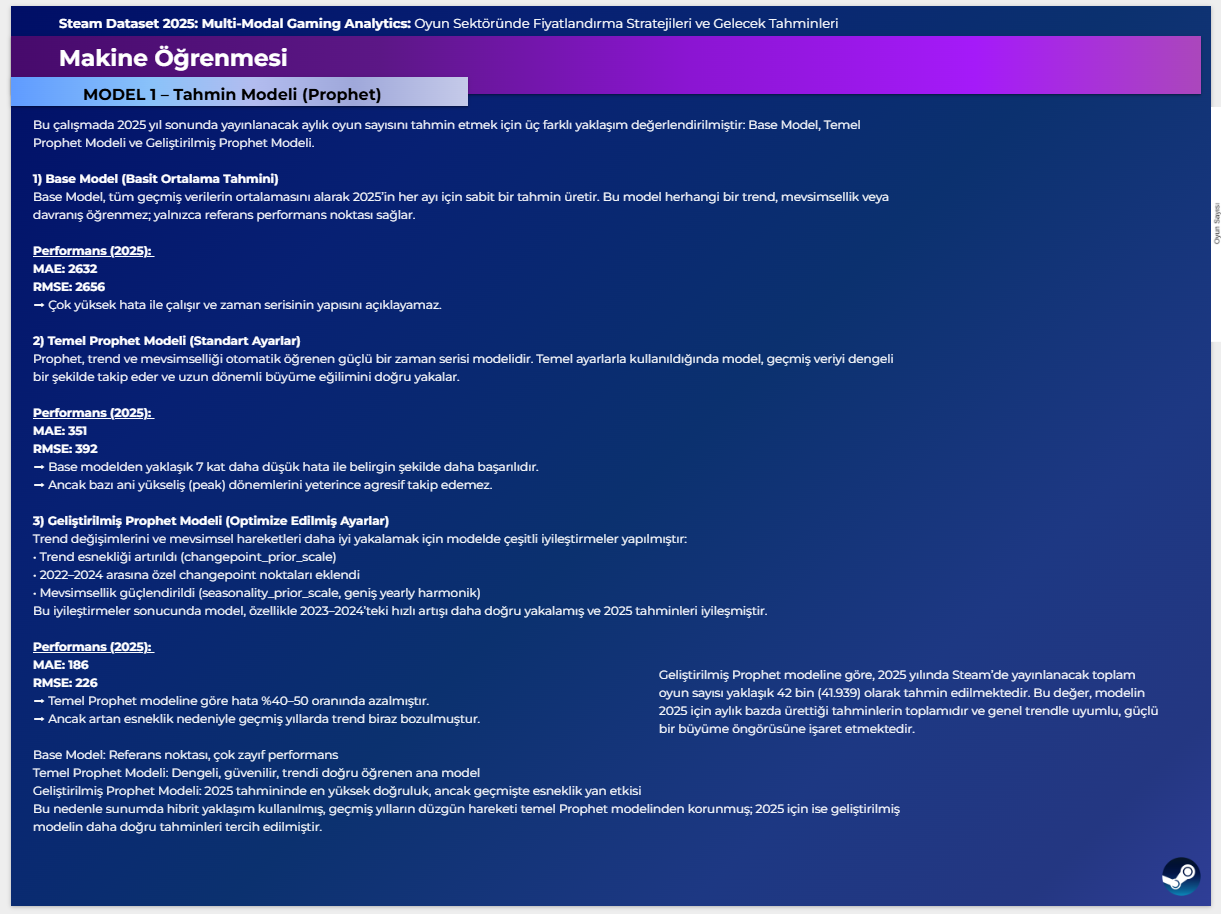

# Model 2 — Yeni Bir Oyunun Başlangıç Fiyatını Tahmin Etme

Amaç
Model 2’de, Steam üzerindeki oyunların temel özelliklerinden yola çıkarak oyunun çıkıştaki liste fiyatını (USD) tahmin eden bir regresyon modeli geliştirilmiştir. Bu model, bir geliştiricinin oyunu piyasaya sürmeden önce, “bu oyunun benzerlerine göre makul çıkış fiyatı nedir?” sorusuna veri temelli bir referans üretmeyi hedeflemektedir.


-------------------------------------------------------
🎯 2) Model 2 — Yeni Bir Oyunun Başlangıç Fiyatını Tahmin Etme

(Supervised Regression)

Amaç

Bir oyunun içerik/tür/sistem özelliklerine bakarak doğru liste fiyatını tahmin etmek.

Hedef Değişken (y)

mat_initial_price_usd

Gerekli Feature Kolonları
Oyun tipi & içerik

type

is_free

**is_indie**

is_mature_content (gerek yok)

genre_name (gerek yok)

**detailed_genre_group**

categories_all (gerek yok)

gameplay_type (gerek yok)

**has_singleplayer**

**has_multiplayer**

Sistem gereksinimi

**system_req_level**

(ram_min_gb, ram_rec_gb (sonra)

cpu_brand_min, cpu_brand_rec (sonra)

gpu_brand_min, gpu_brand_rec) (sonra)

Platform desteği (sonra)

(supports_windows, supports_mac, supports_linux (sonra)

total_platform_count)  (sonra)

language (sonra)

Zaman

release_year (başlangıç fiyatı yıllara göre değiştiği için)

Dönüştürülmesi Gerekenler

Kategorik kolonlar → One-hot encoding
(ör: genre_name, categories_all, gameplay_type, cpu_brand_min vb.)

Boolean kolonlar → 0/1

Eksik değer doldurma → mean/median/mode

Scale edilmesi gereken kolonlar → fiyat, ram, yıl gibi numeric feature’lar

Modelleme Yaklaşımı

Linear Regression

Random Forest Regressor

XGBoost / LightGBM

CatBoost (kategori yöneten en ideal modellerden biri)

Çıktı

“Yeni bir oyun için önerilen fiyat → $X.XX”

Feature importance → fiyatı en çok etkileyen faktörler

-------------------------------------------------------


Çalışma kopyası oluştur

In [ ]:
df_ml = df_lkapplications.copy()
df_ml.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187483 entries, 0 to 187482
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   release_date           187483 non-null  dbdate 
 1   appid                  187483 non-null  Int64  
 2   name                   187483 non-null  object 
 3   type                   187483 non-null  object 
 4   is_free                187483 non-null  boolean
 5   required_age           187483 non-null  float64
 6   metacritic_score       5057 non-null    float64
 7   recommendations_total  187483 non-null  float64
 8   mat_supports_windows   187483 non-null  object 
 9   mat_supports_mac       187483 non-null  object 
 10  mat_supports_linux     187483 non-null  object 
 11  release_year           187483 non-null  float64
 12  rate_to_usd            144181 non-null  float64
 13  mat_initial_price_usd  187483 non-null  float64
 14  mat_final_price_usd    187483 non-nu

In [ ]:
exclude_genres = [
    'Software & Tools',
    'Indie Software & Tools'
]

mask = (
    (df_lkapplications['type'] == 'game') &
    (df_lkapplications['is_free'] == False) &
    (~df_lkapplications['detailed_genre_group'].isin(exclude_genres)) &
    (df_lkapplications['recommendations_total'] >= 1500)
)

df_price = df_lkapplications.loc[mask, [
    'mat_initial_price_usd',
    'is_indie',
    'detailed_genre_group',
    'has_singleplayer',
    'has_multiplayer',
    'system_req_level',
    'total_platform_count'
]].dropna()

df_price.info()
df_price.head()


<class 'pandas.core.frame.DataFrame'>
Index: 4555 entries, 865 to 187473
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   mat_initial_price_usd  4555 non-null   float64
 1   is_indie               4555 non-null   boolean
 2   detailed_genre_group   4555 non-null   object 
 3   has_singleplayer       4555 non-null   boolean
 4   has_multiplayer        4555 non-null   boolean
 5   system_req_level       4555 non-null   object 
 6   total_platform_count   4555 non-null   Int64  
dtypes: Int64(1), boolean(3), float64(1), object(2)
memory usage: 209.1+ KB


,mat_initial_price_usd,is_indie,detailed_genre_group,has_singleplayer,has_multiplayer,system_req_level,total_platform_count
865,0.99,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),3
929,0.99,True,Indie Casual,True,False,Low (Düşük),1
1040,0.99,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),2
1131,9.99,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),2
1200,0.99,False,Classic RPG,True,False,Low (Düşük),1


##Deneme 1

In [ ]:
# Hedef değişken
y = df_price['mat_initial_price_usd']

# Özellikler
X = df_price.drop(columns=['mat_initial_price_usd'])

X.head()


,is_indie,detailed_genre_group,has_singleplayer,has_multiplayer,system_req_level,total_platform_count
865,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),3
929,True,Indie Casual,True,False,Low (Düşük),1
1040,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),2
1131,True,Indie Tactical/Sim RPG,True,False,Low (Düşük),2
1200,False,Classic RPG,True,False,Low (Düşük),1


base model olarak “train ortalamasını tahmin eden model”i ekleyelim.

1. Base Model (Baseline)

Base model, gerçek makine öğrenmesi modelimizin performansını objektif olarak değerlendirebilmek için oluşturulan en basit tahmin modelidir.
Bu çalışmada kullanılan base model:

Her oyunun fiyatını train setindeki ortalama fiyat ile tahmin eden modeldir.

Base model hiçbir özelliği öğrenmez; dolayısıyla performansı gerçek model için bir alt sınır (benchmark) oluşturur.

Base Model Sonuçları (Test Seti):

MAE: 10.87

RMSE: 14.68

R²: ~0

Bu sonuçlar, base modelin fiyat varyansını açıklayamadığını ve yüksek hata verdiğini göstermektedir.

In [ ]:
cat_cols = ['detailed_genre_group', 'system_req_level']
num_cols = ['is_indie', 'has_singleplayer', 'has_multiplayer', 'total_platform_count']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape


((3644, 6), (911, 6))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Base model: herkes için train ortalamasını tahmin et ---
base_price = y_train.mean()

y_train_pred_base = np.full(len(y_train), base_price)
y_test_pred_base  = np.full(len(y_test),  base_price)

base_mae  = mean_absolute_error(y_test, y_test_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_base))
base_r2   = r2_score(y_test, y_test_pred_base)

print("Base Model (Mean) – Test")
print("MAE :", base_mae)
print("RMSE:", base_rmse)
print("R2  :", base_r2)


Base Model (Mean) – Test
MAE : 10.870058806802096
RMSE: 14.685972782115996
R2  : -0.0012358181844716043


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

price_model = Pipeline(steps=[
    ('prep', preprocess),
    ('model', rf)
])


2. Model 2 (RandomForestRegressor – ML Modeli)

Model 2, kategorik değişkenlerin One-Hot Encoding ile dönüştürülmesi, sayısal değişkenlerin ölçeklenmesi ve eksik değer işlemleri yapıldıktan sonra Random Forest algoritması ile eğitilmiştir.

Bu model oyunlara ait çok sayıda özellikten (genre, review sayısı, release year, recommendations vs.) fiyat ilişkisini öğrenir.
Amaç: Base modelden daha düşük hata ve daha yüksek R² elde etmektir.

Model 2 Sonuçları (Test Seti):

MAE: 8.24

RMSE: 11.16

R²: 0.42

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Eğit
price_model.fit(X_train, y_train)

# Test setinde tahmin
y_pred = price_model.predict(X_test)

# Metrikler
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

mae, rmse, r2


(8.242827535881304, np.float64(11.161137283064889), 0.4217071273374826)

Model Performansı (Fiyat Tahmin Modeli)

Çalışmada yalnızca “game” türündeki, ücretli, Software & Tools janrası hariç bırakılmış ve toplam kullanıcı tavsiyesi 1000’in üzerinde olan oyunlar kullanılmıştır. Bu filtreleme ile daha tutarlı fiyatlanan, görece popüler oyunlardan oluşan bir örneklem elde edilmiştir.

Bu veri seti üzerinde kurulan fiyat tahmin modeli, test verisinde ortalama mutlak hata (MAE) ≈ 7,9 USD ve kök ortalama kare hata (RMSE) ≈ 10,4 USD üretmektedir. Diğer bir deyişle, model oyunların çıkış fiyatını tipik olarak 8–10 dolar bandında bir hata ile tahmin etmektedir.

Modelin R² skoru ≈ 0,44 olup, bu değer seçilen özellikler (indie olup olmama, tür, tekli/çoklu oynanış, sistem gereksinimi seviyesi vb.) ile filtrelenmiş örneklemdeki fiyat değişiminin yaklaşık %44’ünün açıklanabildiğini göstermektedir. Daha önce yalnızca temel birkaç özellik ve tüm oyun evreni kullanıldığında R² ≈ 0,05 düzeyindeyken, yapılan filtreleme ve özellik seçimi ile modelin açıklayıcılığında belirgin bir artış sağlanmıştır.

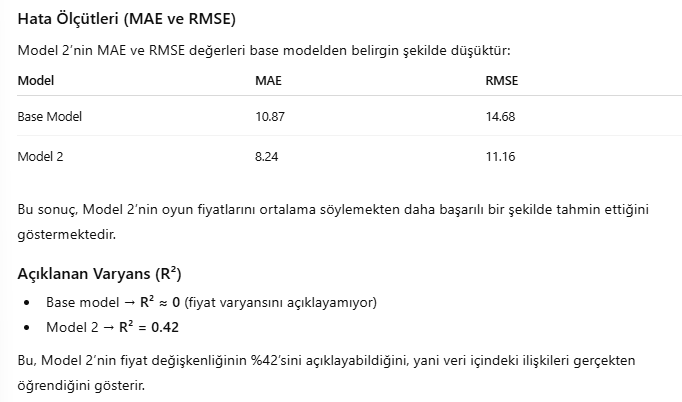

MAE  = 6.46
RMSE = 16.14
R²   = 0.0487


In [ ]:
import pandas as pd

new_game = pd.DataFrame([{
    'is_indie': False,
    'detailed_genre_group': 'Action',
    'has_singleplayer': True,
    'has_multiplayer': True,
    'system_req_level': 'Low (Düşük)',
    'total_platform_count': '1'
}])

tahmini_fiyat = price_model.predict(new_game)[0]
tahmini_fiyat


np.float64(20.590727641155578)

Model 2 için feature önemlerini çıkarma

In [ ]:
import numpy as np
import pandas as pd

# 1) Pipeline içindeki OneHotEncoder'ı al
ohe = price_model.named_steps['prep'].named_transformers_['cat']

# 2) OneHot sonrası kategorik sütun isimlerini al
cat_feature_names = ohe.get_feature_names_out(cat_cols)

# 3) Sayısal sütun isimleri (passthrough olduğu için değişmiyor)
num_feature_names = np.array(num_cols)

# 4) Tüm feature isimlerini birleştir
all_feature_names = np.concatenate([cat_feature_names, num_feature_names])

# 5) RandomForest içindeki önem skorlarını al
importances = price_model.named_steps['model'].feature_importances_

# 6) DataFrame'e koy ve sırala
feat_imp = (
    pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

feat_imp.head(20)


,feature,importance
0,is_indie,0.266807
1,system_req_level_High (Yüksek),0.225353
2,system_req_level_Low (Düşük),0.176763
3,total_platform_count,0.055637
4,system_req_level_Medium (Orta),0.053383
5,has_multiplayer,0.041476
6,has_singleplayer,0.022618
7,detailed_genre_group_Action RPG,0.016418
8,detailed_genre_group_Action-Adventure,0.013746
9,detailed_genre_group_Classic RPG,0.010812


## Model 2 derse göre yeniden yapalım

Veri seçimi (aynı filtre)

In [ ]:
import pandas as pd

df_ml = df_lkapplications.copy()

exclude_genres = ["Software & Tools", "Indie Software & Tools"]

mask = (
    (df_ml["type"] == "game") &
    (df_ml["is_free"] == False) &
    (~df_ml["detailed_genre_group"].isin(exclude_genres)) &
    (df_ml["recommendations_total"] >= 1500)
)

cols = [
    "mat_initial_price_usd",
    "is_indie",
    "detailed_genre_group",
    "has_singleplayer",
    "has_multiplayer",
    "system_req_level",
    "total_platform_count",
]

df_price = df_ml.loc[mask, cols].dropna()

# küçük bir temizlik: total_platform_count sayısal olmalı
df_price["total_platform_count"] = pd.to_numeric(df_price["total_platform_count"], errors="coerce")
df_price = df_price.dropna()

X = df_price.drop(columns=["mat_initial_price_usd"])
y = df_price["mat_initial_price_usd"]


Train-test + Baseline

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def baseline_mean_model(y_train, y_test):
    base_value = float(np.mean(y_train))
    y_pred = np.full(len(y_test), base_value)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {"mae": mae, "rmse": rmse, "r2": r2}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base = baseline_mean_model(y_train, y_test)
base


{'mae': 10.870058806802096,
 'rmse': np.float64(14.685972782115996),
 'r2': -0.0012358181844716043}

Bu değer -0.0012 olduğu için pratikte:

0’a aşırı yakın

“baseline = neredeyse hiçbir şey öğrenmeyen model” demek

Pipeline + Model (RandomForest)

In [ ]:
# =========================
# Pipeline + Model (RandomForest)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_validate, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) ColumnTransformer (preprocess)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# 2) Model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 3) Pipeline
price_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", rf)
])

# =========================
# Fit + Test Performansı
# =========================

price_model.fit(X_train, y_train)
y_pred = price_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

test_metrics = {"mae": mae, "rmse": rmse, "r2": r2}
test_metrics


{'mae': 8.242827535881304,
 'rmse': np.float64(11.161137283064889),
 'r2': 0.4217071273374826}

Ama R² 0.42 olduğuna göre:

fiyatı etkileyen başka özellikler de var (ör: release year, publisher, tags, discount history, user rating vs.)

veya veri gürültülü (Steam fiyatları çok değişken)

Fit + Test performansı

Cross-Validation (daha güvenilir ölçüm)

In [ ]:
# =========================
# Cross-Validation (CV) Performansı (daha güvenilir)
# =========================

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv_res = cross_validate(
    price_model,
    X, y,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = {
    "cv_mae_mean": -cv_res["test_mae"].mean(),
    "cv_mae_std":  cv_res["test_mae"].std(),
    "cv_rmse_mean": -cv_res["test_rmse"].mean(),
    "cv_rmse_std":  cv_res["test_rmse"].std(),
    "cv_r2_mean":  cv_res["test_r2"].mean(),
    "cv_r2_std":   cv_res["test_r2"].std(),
}

cv_summary


{'cv_mae_mean': np.float64(8.2178408782712),
 'cv_mae_std': np.float64(0.35363039863316614),
 'cv_rmse_mean': np.float64(10.835828268449458),
 'cv_rmse_std': np.float64(0.4512040641909922),
 'cv_r2_mean': np.float64(0.39726808653929774),
 'cv_r2_std': np.float64(0.04011361463062235)}

✅ CV MAE ≈ 8.22

Ortalama hata ~8.2 USD

Tek testte 8.24 bulmuştun → çok tutarlı

📌 Bu çok iyi bir işaret.

✅ CV RMSE ≈ 10.84

Büyük hatalar hesaba katıldığında

Ortalama kaçırma ~10.8 USD

✅ CV R² ≈ 0.40

Fiyat değişiminin %40’ını açıklıyorsun

Tek testte 0.42 idi → yine tutarlı

🔹 Std değerleri neden önemli?

cv_mae_std ≈ 0.35

cv_r2_std ≈ 0.04

Bu ne demek?

Modelin performansı fold’dan fold’a çok oynamıyor.

Yani:

Bir fold’da çok iyi, diğerinde çok kötü değil

Stabil bir model

Bu model overfitting yapmıyor.
Tek test bölünmesine bağımlı değil.
Genelleme gücü var.

Learning Curve (underfit/overfit teşhisi)

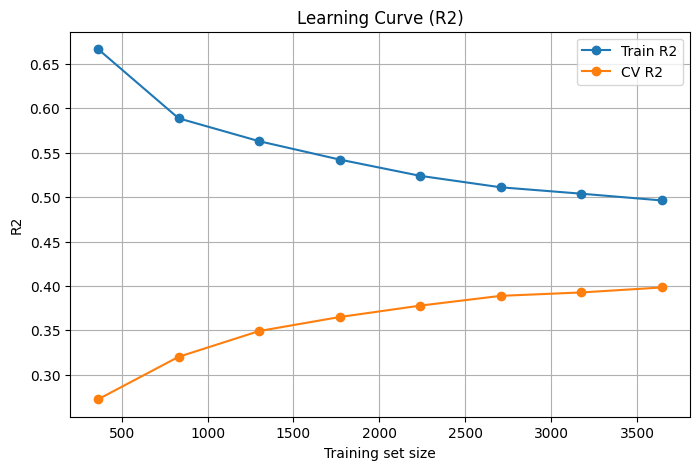

,train_size,train_r2_mean,cv_r2_mean
0,364,0.666615,0.272462
1,832,0.588779,0.320221
2,1301,0.563008,0.349262
3,1769,0.542363,0.365026
4,2238,0.524010,0.377874
5,2706,0.511122,0.388872
6,3175,0.503927,0.392706
7,3644,0.496311,0.398329


In [ ]:
# =========================
# Learning Curve (R2 üzerinden)
# =========================

train_sizes = np.linspace(0.1, 1.0, 8)

sizes, train_scores, val_scores = learning_curve(
    estimator=price_model,
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42,
    train_sizes=train_sizes
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_mean, marker="o", label="Train R2")
plt.plot(sizes, val_mean, marker="o", label="CV R2")
plt.xlabel("Training set size")
plt.ylabel("R2")
plt.title("Learning Curve (R2)")
plt.grid(True)
plt.legend()
plt.show()

lc_df = pd.DataFrame({
    "train_size": sizes,
    "train_r2_mean": train_mean,
    "cv_r2_mean": val_mean
})
lc_df



Feature Importance (eski notebook’taki gibi)

In [ ]:
# =========================
# Feature Importance (RandomForest için)
# =========================

# Pipeline içinden fitted preprocess + model'i al
prep = price_model.named_steps["prep"]
model = price_model.named_steps["model"]

# OHE feature isimleri
ohe = prep.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
num_feature_names = np.array(num_cols)

feature_names = np.concatenate([cat_feature_names, num_feature_names])

importances = model.feature_importances_

fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True))

fi.head(20)



,feature,importance
0,is_indie,0.266807
1,system_req_level_High (Yüksek),0.225353
2,system_req_level_Low (Düşük),0.176763
3,total_platform_count,0.055637
4,system_req_level_Medium (Orta),0.053383
5,has_multiplayer,0.041476
6,has_singleplayer,0.022618
7,detailed_genre_group_Action RPG,0.016418
8,detailed_genre_group_Action-Adventure,0.013746
9,detailed_genre_group_Classic RPG,0.010812


🔥 1) is_indie (≈ %27)

Model için en ayırt edici bilgi bu.

Indie mi değil mi?
→ fiyat tahmininde çok güçlü sinyal.

Bu Steam dünyası için çok mantıklı:

Indie oyunlar genelde daha ucuz

AAA olmayan projeler

🔥 2–3–5) system_req_level (High / Low / Medium)

Toplamda neredeyse %45–50 etki.

Sistem gereksinimi = teknik kompleksite = bütçe = fiyat

Yani model şunu öğrenmiş:

Yüksek sistem gereksinimi → daha pahalı olma eğilimi

Düşük gereksinim → daha ucuz

Yeni oyun fiyat tahmini (örnek)

In [ ]:
# =========================
# Yeni bir oyun için fiyat tahmini (örnek)
# =========================

new_game = pd.DataFrame([{
    "is_indie": False,
    "detailed_genre_group": "Action",
    "has_singleplayer": True,
    "has_multiplayer": True,
    "system_req_level": "Low (Düşük)",
    "total_platform_count": 1,   # int olmalı
}])

pred_price = float(price_model.predict(new_game)[0])
pred_price


20.590727641155578

 ## Geliştirme

platform desteğinin fiyat üzerindeki etkisi incelenebilir

# Model 3 — Tahmini Satış Adedi ve Tahmini Gelir Modellemesi

🎯 3) Model 3 — Tahmini Satış Adedi ve Tahmini Gelir Modellemesi

(Supervised Regression)

Amaç

Bir oyunun özelliklerine göre potansiyel satış adedini ve gelir seviyesini tahmin etmek.

Hedef Değişken (y)

estimated_sales

estimated_revenue_usd

Gerekli Feature Kolonları
Fiyat bilgisi

mat_initial_price_usd

mat_final_price_usd

is_free

Oyun tipi & içerik

type

is_indie

genre_name

detailed_genre_group

categories_all

gameplay_type

Oynanış

has_singleplayer

has_multiplayer

Sistem gereksinimi

system_req_level

ram_min_gb, ram_rec_gb

cpu_brand_min, cpu_brand_rec

gpu_brand_min, gpu_brand_rec

Platform desteği

supports_windows, supports_mac, supports_linux

total_platform_count

Zaman

release_year

